In [1]:
import os
import sys
import joblib
import re
import random

import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset
import torch

# Metadata

## флаги отладки, ускоряющие повторный прогон
**NB!:** при полном прогоне все флаги установлены в `True`

In [2]:
running_in_cloud = False                  # финальный прогон будет на VM в облаке без выполнения локальных сейвов
download_wikitext = False                 # выбор источника датасета - интернет ресурсы библиотеки или локальный сейв

## глобальные параметры выполнения кода

In [3]:
# Фиксируем seed для воспроизводимости
random.seed(42)
torch.manual_seed(42)


seq_len_thres = 32             # длина последовательности токенов в объектах модели, на которых будет инференс

# Этап 1.  Загрузка и подготовка данных


## loading dataset

In [4]:

if download_wikitext:
    dataset = load_dataset("wikitext", "wikitext-2-raw-v1")
    if not running_in_cloud:
        joblib.dump(dataset, os.path.join('.','data','wikitext2dataset.joblib'))
else:
    if running_in_cloud:
        sys.exit('FYI: debug flags mismatch: you are supposed to load data from the net when rinning in the cloud')
    else:
        dataset = joblib.load(os.path.join('.','data','wikitext2dataset.joblib'))

## first look at data

In [5]:
dataset

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})

In [6]:
dataset['train']

Dataset({
    features: ['text'],
    num_rows: 36718
})

In [7]:
print(type(dataset['train']['text']))                    # проверим тип данных
print('='*80, '\n')

print(dataset['train']['text'][:5])                      # топ списка
print('='*80, '\n')
      
for i, s in enumerate(dataset['train']['text'][:5]):   # выведем поэлементно с нумерацией
    if len(s) == 0:
        print(i, '  ', '<empty string>')                 # сделаем видимыми пустые строки
    else:
        print(i, '  ', s)
print('='*80, '\n')

for i, s in enumerate(dataset['train']['text'][:5]):
    s = s.strip('\n').strip()                        # похоже, строки списка содержат "\n" на конце и пробелы
    if len(s) == 0:
        print(i, '  | len =', str(len(s)).rjust(3), '|  ', '<empty string>')
    else:
        print(i, '  | len =', str(len(s)).rjust(3), '|  ', s)

<class 'list'>

['', ' = Valkyria Chronicles III = \n', '', ' Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and follows the " Nameless " , a penal military unit serving the nation of Gallia during the Second Europan War who perform secret black operations and are pitted against the Imperial unit " Calamaty Raven " . \n', " The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the series , it also underwent multiple adjustments , such as making the

## len-EDA

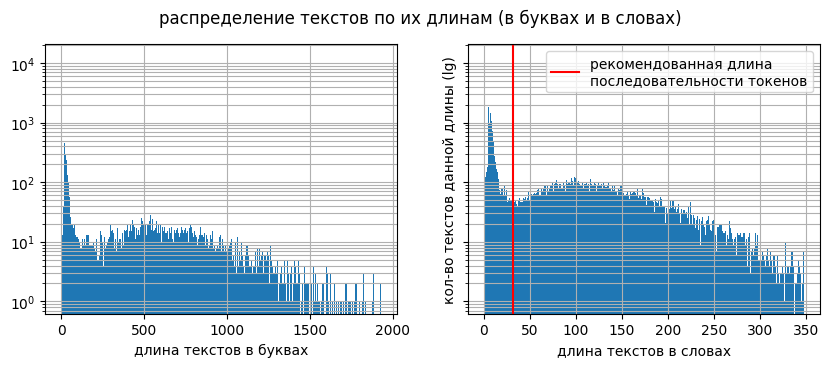

In [8]:
len_in_chars = [ len(el) for el in dataset['train']['text'] ]
len_in_words = [ len(el.split()) for el in dataset['train']['text'] ]

fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(10,3.5), sharey=True)

ax1.hist(len_in_chars, bins=range(max(len_in_chars)//2))
ax1.set_yscale('log')
ax1.grid(which='both')
ax1.set_xlabel('длина текстов в буквах')

ax2.hist(len_in_words, bins=range(max(len_in_words)//2))
ax2.set_yscale('log')
ax2.grid(which='both')
ax2.set_xlabel('длина текстов в словах')
ax2.set_ylabel('кол-во текстов данной длины (lg)')
ax2.axvline(seq_len_thres, color='red', label='рекомендованная длина\nпоследовательности токенов')
ax2.legend(loc='upper right')

fig.suptitle('распределение текстов по их длинам (в буквах и в словах)')
plt.show()

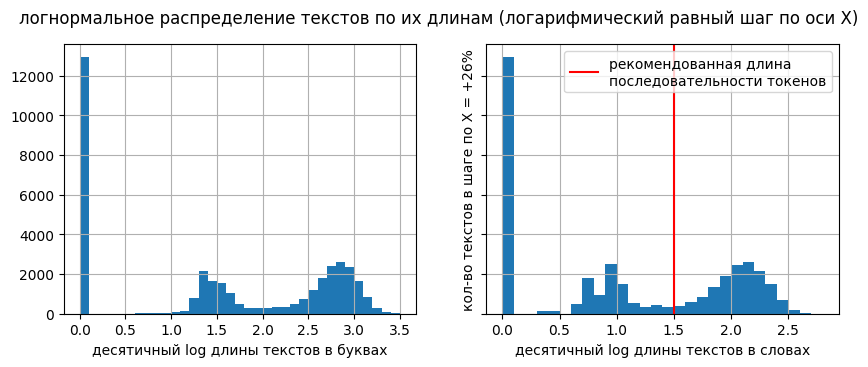

In [9]:
lg_len_in_chars = np.log(np.array(len_in_chars)+1) / np.log(10)   # если убрать прибавление 1, то код будет работать,
lg_len_in_words = np.log(np.array(len_in_words)+1) / np.log(10)   # но полностью исчезнет нулевая мода на графиках

fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(10,3.5), sharey=True)

ax1.hist(lg_len_in_chars, bins=[ 0.1*i for i in range(int(max(lg_len_in_chars)*10)+1)] )
ax1.grid(which='both')
ax1.set_xlabel('десятичный log длины текстов в буквах')

ax2.hist(lg_len_in_words, bins=[ 0.1*i for i in range(int(max(lg_len_in_words)*10)+1)] )
ax2.grid(which='both')
ax2.set_xlabel('десятичный log длины текстов в словах')
ax2.set_ylabel('кол-во текстов в шаге по X = +'+str(round((10**0.1-1)*100))+'%')
ax2.axvline(np.log(seq_len_thres)/np.log(10), color='red', label='рекомендованная длина\nпоследовательности токенов')
ax2.legend(loc='upper right')

fig.suptitle('логнормальное распределение текстов по их длинам (логарифмический равный шаг по оси X)')
plt.show()

**ВЫВОДЫ ИЗ ГРАФИКОВ:**
* В логнормальных координатах отчетливо выявляются три моды текстов:
  * совсем короткие, практически все они просто пустые
  * короткие - порядка десятка слов
  * полные - порядка сотни слов и длиннее
* `np.log(x)` справляется и с нулевым аргументом, выдавая минус бесконечность, которую не отрисует `matplotlib`, но мы добавляли к x +1 под логарифмом - чтобы вернуть на график все тексты.
* Рекомендуемая длина последовательности токенов 32 при предлагаемой токенизации словами идеально фильтрует только последнюю моду, удаляя две другие как шум - что разумно, так как статистика (и логика за ней) фразообразования в каждой моде, скорее всего, разная:  примерно также, как статистика продолжения фразы на заборе сильно отличается от таковой в художественном романе!

## raw preprocessing
теперь, когда минимальную длину текста в словах мы обосновали, можно проводить большую чистку данных 

In [10]:
def raw_preproc(raw_texts_list, len_thres):
    # удаляем слишком короткие тексты
    texts = [line for line in raw_texts_list if len(line.split()) >= len_thres]

    # функция для "чистки" текстов (из материалов урока)
    def clean_string(text):
        # приведение к нижнему регистру
        text = text.lower()
        # удаление всего, кроме латинских букв, цифр и пробелов
        text = re.sub(r'[^a-z0-9\s]', '', text)
        # удаление дублирующихся пробелов, удаление пробелов по краям
        text = re.sub(r'\s+', ' ', text).strip()
    
        return text

    # "чистим" тексты
    cleaned_texts_list = list(map(clean_string, texts))
    # повторно "обрезаем" коротких
    return [line for line in cleaned_texts_list if len(line.split()) >= len_thres]

### применяем функцию чистки к train/val/test спискам текстов

In [23]:
train_texts = raw_preproc(dataset['train']['text'], seq_len_thres + 1)   # +1 токен для target при обучении и проверке
test_texts = raw_preproc(dataset['test']['text'], seq_len_thres + 1)
val_texts = raw_preproc(dataset['validation']['text'], seq_len_thres + 1)

len(train_texts), len(val_texts), len(test_texts)

(14306, 1509, 1720)

In [22]:
print('Осталось после чистки текстов:')
print('='*30)
print('train      ','val        ','test')
print('-'*30)
print(round(len(train_texts) / len(dataset['train']) *100,1), '%     ',
      round(len(val_texts) / len(dataset['validation']) *100,1), '%     ',
      round(len(test_texts) / len(dataset['test']) *100,1), '%')

Осталось после чистки текстов:
train       val         test
------------------------------
39.0 %      40.1 %      39.5 %
